### BNN classification, ORDINAL target variable, example (red wine dataset)

#### Location of dataset: https://www.kaggle.com/datasets/vishalpnaik/mushroom-classification-edible-or-poisonous/data. The goal is to predict whether a mushroom is edible or poisonous. There are 61069 rows in the dataset. Data analysis locates here: Exercise_project_1\Classification_dataset\dataset_analysis_code.ipynb<br>Target variable is Class (binary, classification). Values: e → edible, p → poisonous.<br>The dataset contains 21 feature columns in addition to the target.

In [1]:
# installations:
# pip install torch
# pip install torchbnn

# REMEMBER: GPU is actually slower in BNN training 
# (unless using Pyro-module or something else)

import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

### Load, process and optimize your data in this part

In [ ]:
df = pd.read_csv("mushroom.csv")
target_variable = "class"

In [ ]:
# This dataset is very messy, many missing values, many columns are categorical. I already preprocessed it in other course
# so, I will paste here the link to the notebook where i did it:
# https://github.com/RovSveta/Advanced_Data_analytics_2025/blob/main/Exercise_project_1/Classification_dataset/dataset_analysis_code.ipynb
df.head(5)

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [23]:
# DO ANY OPTIMIZATIONS, data cleanups etc here

### X/y, train/test/val -split etc

In [24]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# get unique values in target variable
categories = list(np.unique(df[target_variable]))

# Split features and target
X = df.drop(columns=[target_variable]).values
y = df[target_variable].values

# let's encode our target from the original, eg. 3,4,5,6,7,8 to 0,1,2,3,4,5
le = LabelEncoder()
y = le.fit_transform(y)

# if bad result, consider shuffling the dataset just in case
# normalize variables
scaler = StandardScaler()
X = scaler.fit_transform(X)

# train/test, 80% for training, remaining 20% for test/val
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# split into test and validation (50% in half)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# convert to PyTorch tensor format
X_train, X_test, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
y_train, y_test, y_val = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_test, dtype=torch.long), torch.tensor(y_val, dtype=torch.long) 

# create PyTorch dataloaders, YOU CAN ADJUST THE BATCH SIZES IF YOU WISH
# basic rule: bigger batch size => faster training, but more memory needed
# only shuffle the training dataset, NEVER SHUFFLE TEST/VAL
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)


### Hyperparameters and other configurables for the BNN

In [25]:
# all common hyperparameters we can finetune in the future

# sigma = standard deviation of the noise term (this is often optimized)
# if model is too confident and OVERFITS at the same time, INCREASE sigma
# if predictions are too noisy, too much variation or uncertain  => DECREASE sigma
# COMMON VALUES 0.1 - 0.5

# lambda_kl = amount of KL in the loss function => regularization parameter to avoid OVERFITTING
# if model overfits => increase, if model underfits => decrease
# COMMON VALUES 0.0+ - 0.2

# mu = mean of distribution (you can usually use the default 0 in classification)
# if model "overfits" => decrease mu
# if model "underfits" => increase mu
# mu = 0 => it's assumed values are centered around 0 (similar to having a 
# normal distribution, between -3 to +3 range, but not quite)
# SEE ALSO BELOW: BNN overfit vs. uncertainty

# COMMON VALUES: mu usually 0 in classification

# mc_samples_eval = monte carlo sample size used to approximate distributions in weights
# more samples used => more accurate uncertainty estimation (but heavier to compute)
# if uncertainty is not optimal, try increasing mc_sample -size a little bit
# if model training is too heavy or underfits, you can decrease the sample size
# COMMON VALUES: 25 - 200

mu = 0
sigma = 0.4
lambda_kl = 0.1
mc_samples_eval = 50

# remember to adjust the BNN network structure in the below cell if needed
# amount of layers, layer sizes, amount of dropout regularization etc.

# learning rate is same as in ANN => controls the aggressiveness of optimization
# too large value => model overshoots optimization attempts
# too small value => model learns too slowly
# COMMON VALUES similar to ANN learning rates, small values (0.03 or less), usually 0.1 or less
bnn_learning_rate = 0.001

# weight_decay = regularization applied to model weights (probability distributions)
# penalizes large weights IN ORDER to prevent OVERFITTING
# if model overfits => you can try increasing weight decay, if underfits => try decreasing
# COMMON VALUES are usually quite small, 0.0001 to 0.0005
bnn_weight_decay = 0.0001

### Note: Overfit in BNN and the mu-variable

Overfitting in BNN is slightly different than in conventional ANN/MLP. Generally overfitting means that the model learns the training dataset perfectly, but it doesn't work well with any other dataset than that, e.g. test dataset. (useless model in practice)

Overfitting is a bit more complex in BNN, and it all comes down to the concept of uncertainty.

There are two types of uncertainty in a BNN model: 
- model-specific (epistemic) uncertainty (systematic uncertainty)
- data-specific (aleatoric) uncertainty (inherent randomness)

Model-specific uncertainty is the one we want to minimize, but we don't want to minimize data-specific uncertainty, because it's likely just how the data should work (grey areas in the data, for example, difficult to detect diseases in medical datasets). Model-specific uncertainty usually implies that the model or data are not optimal. Data-specific uncertainty implies uncertainty, that is just part of the data and use case you're working with.

For example, if your uncertainty is low, but conventional metrics are bad => this implies the model doesn't work well, but at the same time, model thinks it's very certain in its predictions.

Most of the time you can aim for good metrics + low uncertainty, but in rare cases this is not as simple as it seems.

<hr>

### Define Bayesian Neural Network for PyTorch

Note: you have to chain the neighboring layers regarding in/out -features. Size of out in previous layer => size of in in next layer.

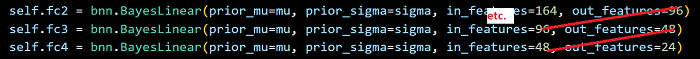

In [26]:
# Bayesian Neural Network -model (BNN) with deeper layers and Monte-Carlo dropout
class BayesianNN(nn.Module):
    def __init__(self, input_dim, output_dim, mu=0, sigma=0.5):
        super().__init__()
        # DEFINE ALL LAYERS THAT WILL BE COMBINED INTO ONE MODEL IN forward()
        # NOTE: Torch requires as to "chain" connected layer => out_features and in_features have to match in connected layers
        # for example "in_features=96, out_features=48" means that previous layers to have out_features of 96
        # and the next layer has to have in features of 48
        self.fc1 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=input_dim, out_features=128)
        self.fc2 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=128, out_features=64)
        self.fc3 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=64, out_features=32)
        self.fc4 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=32, out_features=16)
        self.fc5 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=16, out_features=output_dim)
        self.relu = nn.ReLU()

        # adjust dropout rate to increase regularization
        self.dropout = nn.Dropout(0.3)  

        # THE BATCH NORMALIZATION SIZES HAVE THE MATCH THE OUTPUT OF THE CORRESPONDING LAYER
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(32)
        self.batch_norm4 = nn.BatchNorm1d(16)
    
    # "forward pass", if mc_dropout = True => adds a dropout layer between the BayesLinear -layers
    def forward(self, x, mc_dropout=False):
        # NOTE: batch normalization helps in stabilizing the training process
        x = self.batch_norm1(self.relu(self.fc1(x))) 
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm2(self.relu(self.fc2(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm3(self.relu(self.fc3(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm4(self.relu(self.fc4(x)))
        x = self.dropout(x) if mc_dropout else x
        return self.fc5(x)

### Hyperparameters and model initialization

In [27]:
# model, loss, optimizer
model = BayesianNN(input_dim=X.shape[1], 
                   output_dim=len(np.unique(y)),
                   sigma=sigma,
                   mu=mu
                   )

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss() 

# Bayesian KL Divergence Loss (efficient regularization for BNN)
bkl_loss = bnn.BKLLoss(reduction='mean')  

# AdamW is common in BNN
# AdamW decouples the weight decay from the updates
# usually leading to better regularization/generalization
optimizer = optim.AdamW(model.parameters(), lr=bnn_learning_rate, weight_decay=bnn_weight_decay)

### Create train/evaluate -functions for BNN training/evaluation

In [28]:
# evaluate function with uncertainty estimation
def evaluate(model, loader, mc_samples=mc_samples_eval):
    # set model to evaluation mode
    model.eval() 
    total_correct = 0
    total_samples = 0
    total_loss = 0
    uncertainties = []

    # disable gradient updates during evaluation
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs_list = [model(X_batch, mc_dropout=True) for _ in range(mc_samples)]
            outputs_stack = torch.stack(outputs_list) 

            # average prediction and standard deviation (uncertainty)
            outputs_mean = outputs_stack.mean(dim=0)  
            outputs_std = outputs_stack.std(dim=0)

            loss = criterion(outputs_mean, y_batch)
            total_loss += loss.item()

            probs = torch.softmax(outputs_mean, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy()) 

    # current accuracy, loss and average uncertainty
    accuracy_score = total_correct / total_samples
    nll = total_loss / len(loader) 
    avg_uncertainty = np.mean(uncertainties)  

    print(f"Val Accuracy: {accuracy_score:.4f}, Val loss: {nll:.4f}, Avg. Uncertainty: {avg_uncertainty:.4f}")

    # return per-sample uncertainty if needed
    return accuracy_score, nll, avg_uncertainty, uncertainties  

# training loop with BKLLoss
def train(model, loader, epochs):
    model.train()
    history = {}
    history['train_loss'] = []
    history['val_loss'] = []
    history['val_accuracy'] = []
    history['avg_uncertainty'] = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch, mc_dropout=True)
            
            # compute cross-entropy and BKL loss and combine them
            ce_loss = criterion(outputs, y_batch)
            kl_loss = bkl_loss(model)
            loss = ce_loss + lambda_kl * kl_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(loader):.4f}")

        val_accuracy, val_loss, avg_uncertainty, _ = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['avg_uncertainty'].append(avg_uncertainty)

        # set model to training mode for next epoch
        model.train()
        
    return history

### TRAIN THE BNN MODEL!

In [29]:
# train the model (fit), epochs are usually 1000-5000 with BNN classification
history = train(model, train_loader, epochs=1500)

Epoch 1/1500, Training Loss: 3.0091
Val Accuracy: 0.3875, Val loss: 1.7208, Avg. Uncertainty: 1.2800
Epoch 2/1500, Training Loss: 2.8690
Val Accuracy: 0.3750, Val loss: 1.7647, Avg. Uncertainty: 1.1665
Epoch 3/1500, Training Loss: 2.9129
Val Accuracy: 0.3688, Val loss: 1.7182, Avg. Uncertainty: 1.1232
Epoch 4/1500, Training Loss: 2.8639
Val Accuracy: 0.3875, Val loss: 1.7112, Avg. Uncertainty: 1.1373
Epoch 5/1500, Training Loss: 2.5386
Val Accuracy: 0.3812, Val loss: 1.6668, Avg. Uncertainty: 1.0937
Epoch 6/1500, Training Loss: 2.7760
Val Accuracy: 0.3812, Val loss: 1.6910, Avg. Uncertainty: 1.0359
Epoch 7/1500, Training Loss: 2.6195
Val Accuracy: 0.4000, Val loss: 1.6795, Avg. Uncertainty: 1.0285
Epoch 8/1500, Training Loss: 2.4890
Val Accuracy: 0.4062, Val loss: 1.6630, Avg. Uncertainty: 1.0148
Epoch 9/1500, Training Loss: 2.4667
Val Accuracy: 0.4062, Val loss: 1.6264, Avg. Uncertainty: 1.0118
Epoch 10/1500, Training Loss: 2.4714
Val Accuracy: 0.4125, Val loss: 1.5840, Avg. Uncertain

### Error metrics

In [30]:
# get predictions etc. for test data
model.eval()
y_true = y_test.cpu().numpy()
y_pred = []
y_pred_probs = [] 

with torch.no_grad():
    for X_batch, _ in test_loader:
        # get average outputs, average of 10 predictions for each
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)  
        outputs_mean = outputs_stack.mean(dim=0)  
        preds = torch.argmax(outputs_mean, dim=1)
        probs = torch.softmax(outputs_mean, dim=1)
        y_pred_probs.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


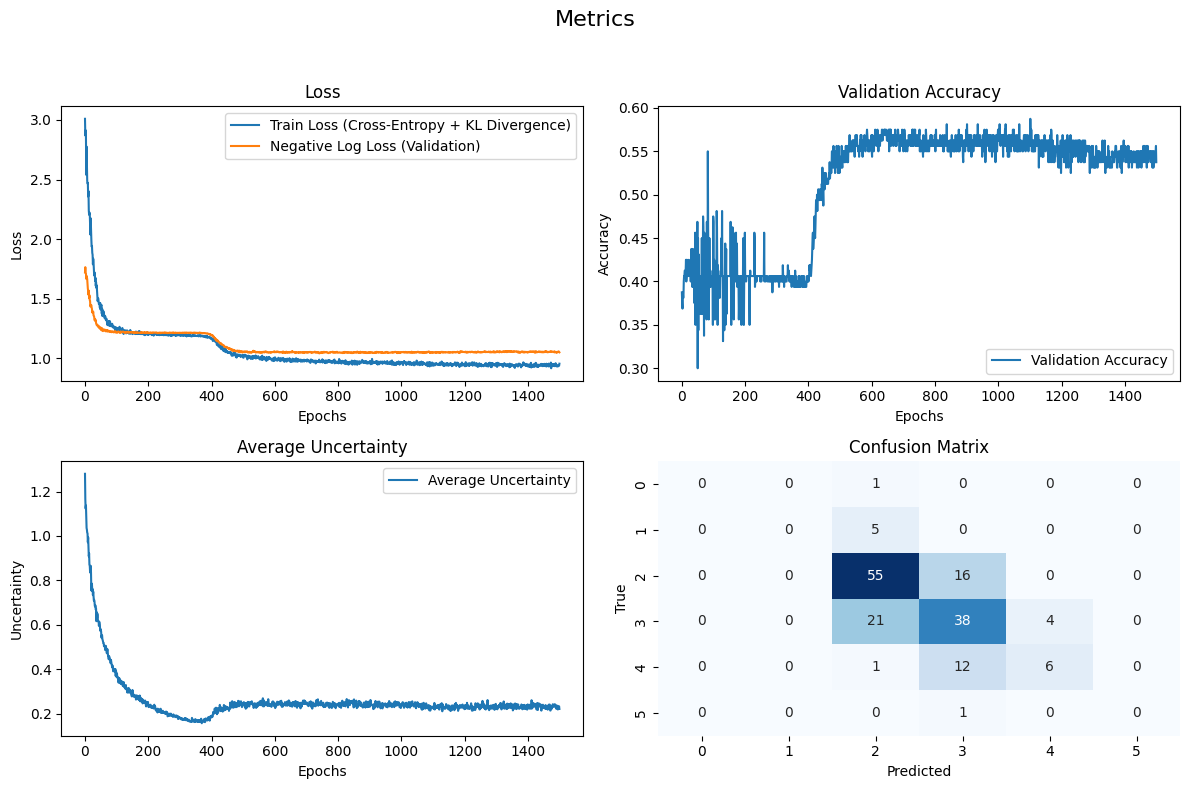

In [31]:
# plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle('Metrics', fontsize=16)

# BNN, losses
axes[0, 0].plot(history['train_loss'], label='Train Loss (Cross-Entropy + KL Divergence)')
axes[0, 0].plot(history['val_loss'], label='Negative Log Loss (Validation)')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# accuracy
axes[0, 1].plot(history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# uncertainty
axes[1, 0].plot(history['avg_uncertainty'], label='Average Uncertainty')
axes[1, 0].set_title('Average Uncertainty')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Uncertainty')
axes[1, 0].legend()

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], vmax=cm.max(), cbar=False)
axes[1, 1].set_title('Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

# combine the four plots into one and show
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [32]:
# the usual classification report
print(classification_report(y_true, y_pred, zero_division=0.0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.66      0.77      0.71        71
           3       0.57      0.60      0.58        63
           4       0.60      0.32      0.41        19
           5       0.00      0.00      0.00         1

    accuracy                           0.62       160
   macro avg       0.30      0.28      0.29       160
weighted avg       0.59      0.62      0.60       160



In [33]:
# ordinal classification, get MSE to evaluate quality of predictions
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse:.4f}")

# quality thresholds:
# less than 0.1         => EXCELLENT RESULT (very good predictions)
# between 0.1 - 0.3     => Good result (small error, but model is generally reliable)
# between 0.3 - 0.5     => Average result (some errors with classifications, needs optimization)
# more than 0.5         => Poor result (significant amount of errors, optimize heavily (data/parameters etc))

MSE: 0.4375


In [34]:
# ROC-AUC -score
y_pred_proba = np.array(y_pred_probs)
labels = np.unique(y)
roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', labels=labels)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.7789


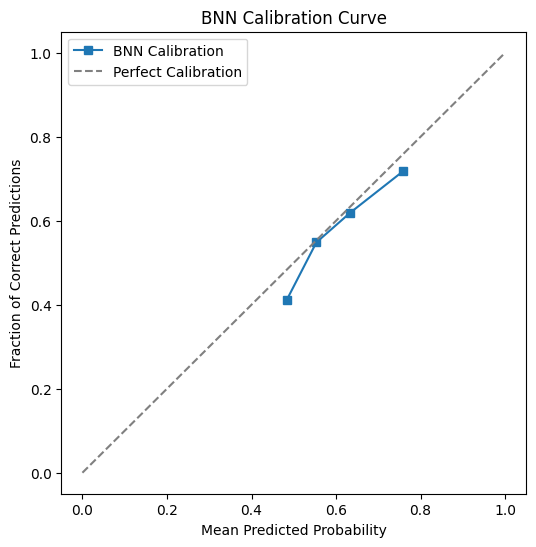

In [35]:
# run Monte Carlo -dropout and return average probabilities + true labels
def get_mc_dropout_predictions(model, dataloader, num_samples=100):
    # evaluation mode + enable dropout at inference (train())
    model.eval()
    model.train() 

    all_probs = []
    all_labels = []

    # no gradient updates
    with torch.no_grad():
        for inputs, labels in dataloader:
            batch_probs = []
            
            # run multiple "forward passes" -> monte carlo sampling
            for _ in range(num_samples): 
                outputs = model(inputs)  
                probs = torch.softmax(outputs, dim=1).cpu().numpy()  
                batch_probs.append(probs)

            # calculate mean probability
            avg_probs = np.mean(batch_probs, axis=0)
            all_probs.append(avg_probs)
            all_labels.append(labels.cpu().numpy())

    return np.vstack(all_probs), np.hstack(all_labels)

# helper function to actually plot the calibration curve
def plot_calibration_curve(model, dataloader, num_samples=100, bins=10):
    # see function above 
    probs, labels = get_mc_dropout_predictions(model, dataloader, num_samples)
    
    # take max probability and corresponding true class
    confidences = np.max(probs, axis=1)  
    predictions = np.argmax(probs, axis=1) 

    # correct predictions 
    correct = (predictions == labels).astype(int) 
    
    # compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(correct, confidences, n_bins=bins)
    
    # plot the calibration curve
    plt.figure(figsize=(6,6))
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="BNN Calibration")
    plt.plot([0,1], [0,1], "--", color="gray", label="Perfect Calibration")
    
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Correct Predictions")
    plt.title("BNN Calibration Curve")
    plt.legend()
    plt.show()

# use current model and test data to create a calibration curve, adjust samples if needed
# might be a good idea to use same amount of samples as in training (mc_samples)
plot_calibration_curve(model, test_loader, num_samples=100)

# calibration curve interpretation:

# perfect calibration = if the curve follows this line, the model is well calibrated
# OVERCONFIDENT => if the curve is BELOW the diagonal, the model assigns higher probabilities than it should
# UNDERCONFIDENT => if the curve is ABOVE the diagonal, the model undershoots it's probability estimations

# how to optimize:
# if overconfident => if categorical classification, try Temperature/Platt-scaling, 
# for other models, adjust hyperparameters, model structure etc.

# if underconfident: get more data or add more regularization

# IF THE LINE IS COMPLETELY MISALIGNED:
# increase MC samples to improve uncertainty estimation

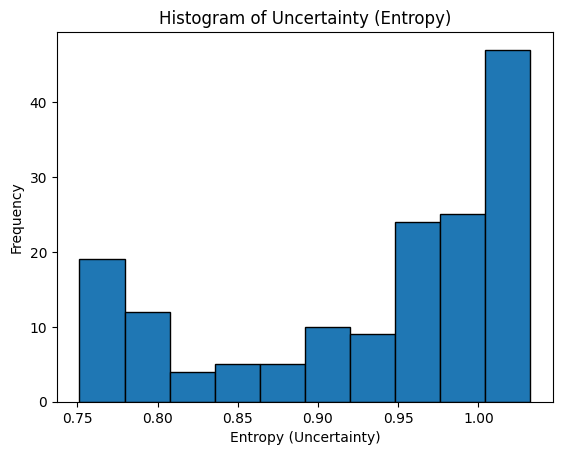

In [36]:
# convert to a numpy array for easier manipulation
y_pred_probs = np.array(y_pred_probs)

# calculate entropy for each sample (sum of -p * log(p) for each class)
entropy = -np.sum(y_pred_probs * np.log(y_pred_probs + 1e-10), axis=1)  # Add small epsilon to avoid log(0)

# plot histogram of entropy
plt.hist(entropy, bins=10, edgecolor='k')
plt.xlabel('Entropy (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Histogram of Uncertainty (Entropy)')
plt.show()

# in optimal case, entropy is stacked on the left side
# with only a small number of uncertainty on the high end

# this particular example is a very bad result, most uncertainty
# is in the high end

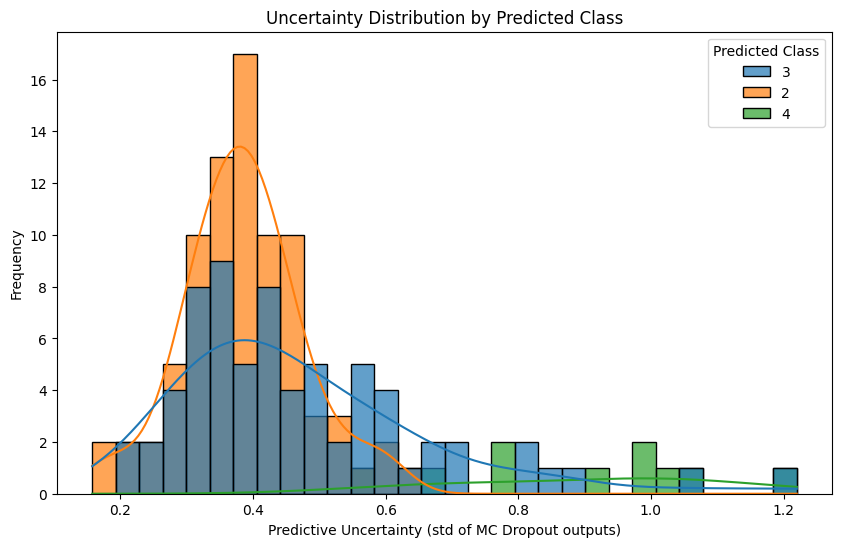

In [37]:
# store predictive uncertainties and predicted classes
uncertainties = []
predicted_classes = []

# perform inference and collect uncertainty metrics for each sample
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)  
        
        # compute mean and std (uncertainty) of predictions
        outputs_mean = outputs_stack.mean(dim=0)  
        outputs_std = outputs_stack.std(dim=0)  

        # convert to probabilities
        probs = torch.softmax(outputs_mean, dim=1).cpu().numpy()
        
        # compute uncertainty as standard deviation of probabilities
        uncertainty_per_sample = outputs_std.mean(dim=1).cpu().numpy()  # Averaged across classes
        
        # get predicted class
        preds = np.argmax(probs, axis=1)

        # store results
        uncertainties.extend(uncertainty_per_sample)
        predicted_classes.extend(preds)

# convert to pandas DataFrame for easier plotting
plot_df = pd.DataFrame({"Uncertainty": uncertainties, "Predicted Class": predicted_classes})

# Convert predicted class to categorical
plot_df["Predicted Class"] = plot_df["Predicted Class"].astype(str)

# plot uncertainty distributions by class
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="Uncertainty", hue="Predicted Class", bins=30, kde=True, palette="tab10", alpha=0.7, legend=True)
plt.xlabel("Predictive Uncertainty (std of MC Dropout outputs)")
plt.ylabel("Frequency")
plt.title("Uncertainty Distribution by Predicted Class")

# quick/dirty fix to avoid the bug with numeric labels for matplotlib
handles, labels = plt.gca().get_legend_handles_labels()
if labels: 
    # add prefix "Class" for each target label (which is a number), e.g. Class 3
    class_labels = [f"Class {l}" for l in labels]  
    plt.legend(handles, class_labels, title="Predicted Class", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()

# might be a good idea to compare this result to confusion matrix to see if the categories match

### Use the model in practice (inference)

In [38]:
# you can adjust the mc_samples to improve uncertainty estimation, 
# values in the range 50-100 are usually ok, sometimes even more
def process_single_row_with_uncertainty(model, input_row, device, mc_samples=50):
    # set model to evaluation mode
    model.eval()  

    # convert input row to a tensor and reshape it to match model input
    input_tensor = torch.tensor(input_row, dtype=torch.float32).unsqueeze(0).to(device)  

    # disable gradient updates, since we are not training at the moment
    with torch.no_grad():  
        # perform multiple forward passes with dropout enabled
        outputs_list = [model(input_tensor, mc_dropout=True) for _ in range(mc_samples)]
        outputs_stack = torch.stack(outputs_list) 

        # compute mean prediction (expected class probabilities)
        outputs_mean = outputs_stack.mean(dim=0).squeeze()  

        # compute uncertainty (standard deviation of probabilities across MC samples)
        outputs_std = outputs_stack.std(dim=0).squeeze()

        # convert logits to probabilities using softmax
        pred_probs = torch.softmax(outputs_mean, dim=0).cpu().numpy()
        pred_uncertainty = outputs_std.cpu().numpy() 

        # predicted class is the one with the highest probability
        pred_class = np.argmax(pred_probs)

    return pred_class, pred_probs, pred_uncertainty

# add your support variable values here for a new row
# this example whould be quality level 8
tester_row = {
    "fixed acidity":            7.8000,
    "volatile acidity":         0.5700,
    "citric acid":              0.09,
    "residual sugar":           2.3000,
    "chlorides":                0.0650,
    "free sulfur dioxide":     34.0000,
    "total sulfur dioxide":    45.0000,
    "density":                  0.99417,
    "pH":                       3.4600,
    "sulphates":                0.7400,
    "alcohol":                  12.7000
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

# get values and scale with same scaler as original training data
input_row = tester_row.values[0]
input_row = scaler.transform([input_row])
input_row = list(input_row[0])

# run the model and get predictions, probabilities and uncertainties
pred_class, pred_probs, pred_uncertainty = process_single_row_with_uncertainty(model, input_row, torch.device('cpu'))

# set print options to suppress scientific notation
np.set_printoptions(suppress=True)

# see the results
print(f"Predicted Class: {pred_class}")
print(f"Predicted Probabilities: {pred_probs}")
print(f"Predictive Uncertainty (per class): {pred_uncertainty}")
print(f"Predicted Class name (original wine quality): {categories[pred_class]}")

# uncertainty is not a percentage, the value can be anything 0 - 150, or even more

Predicted Class: 3
Predicted Probabilities: [0.00006028 0.00162148 0.02842177 0.50610554 0.41966918 0.04412175]
Predictive Uncertainty (per class): [0.56879264 0.4385012  0.33372656 0.10862062 0.32547942 0.48805532]
Predicted Class name (original wine quality): 6
